In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df= pd.read_csv("cleaned_disaster_data.csv")

# EDA and visualization
This section explores temporal trends, disaster type distributions,
and geographic patterns in the FEMA disaster declarations dataset.

: Total Disaster Declarations Per Year

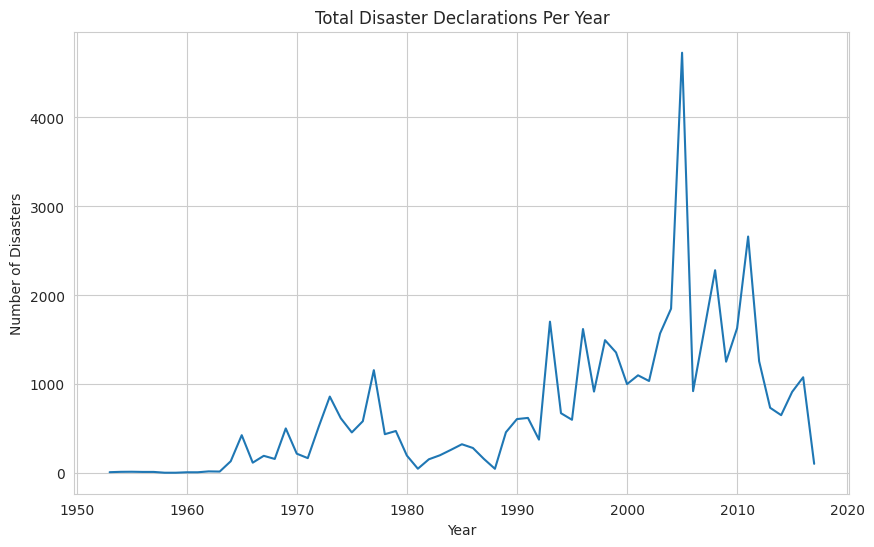

In [2]:
yearly_disasters = df.groupby("year").size()

plt.figure()

yearly_disasters.plot()

plt.title("Total Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

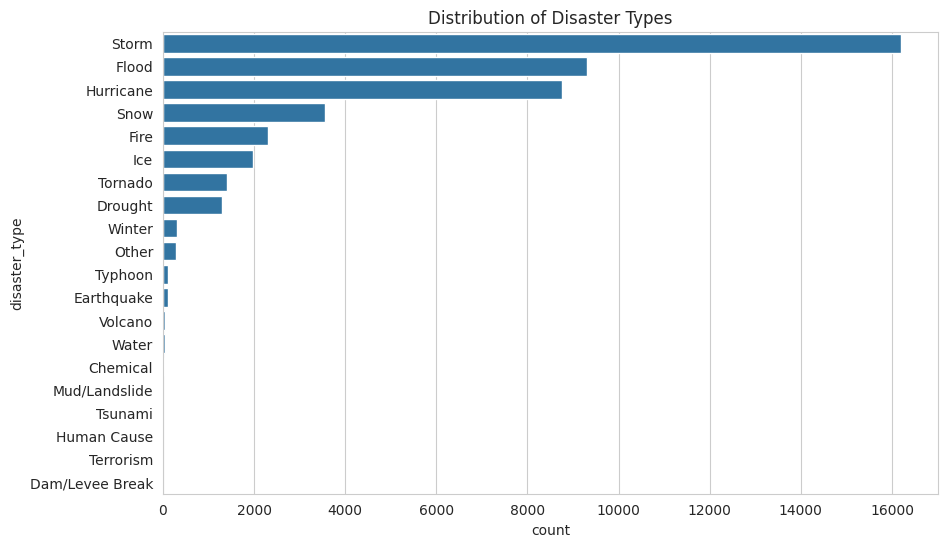

In [3]:
plt.figure()

sns.countplot(
    data=df,
    y="disaster_type",
    order=df["disaster_type"].value_counts().index
)

plt.title("Distribution of Disaster Types")

plt.show()

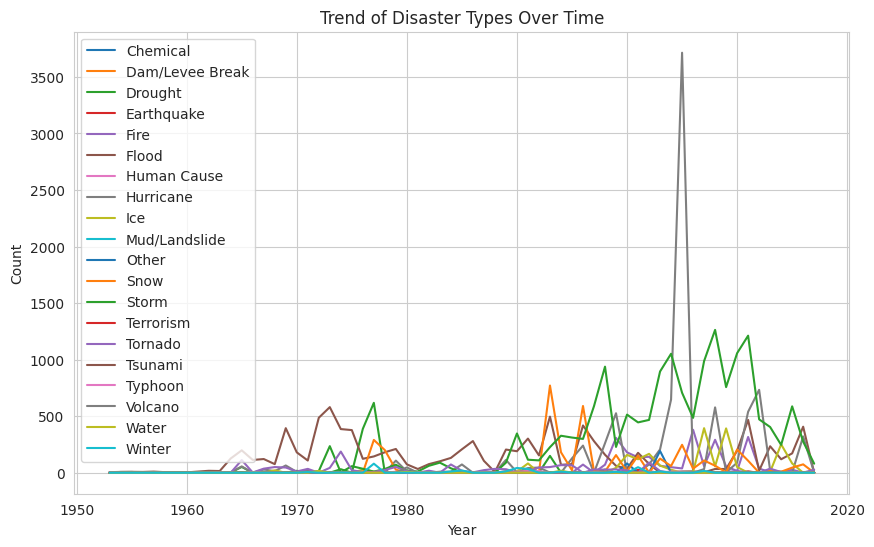

In [4]:
trend = df.groupby(["year", "disaster_type"]).size().unstack().fillna(0)

trend.plot()

plt.title("Trend of Disaster Types Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(loc="best")
plt.show()

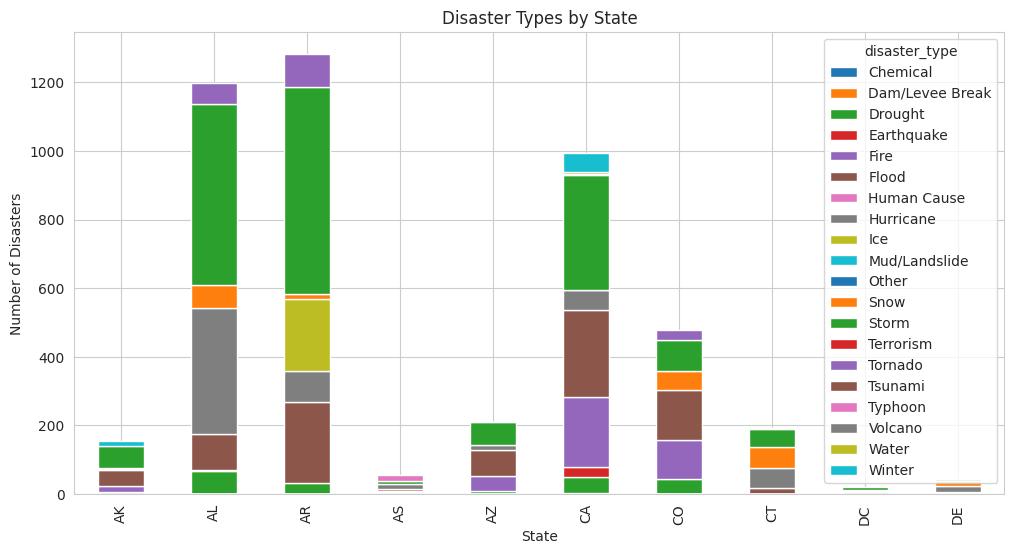

In [5]:
state_disaster = df.groupby(["state", "disaster_type"]).size().unstack().fillna(0)

state_disaster.head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Disaster Types by State")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.show()

#FEMA Assistance Programs Analysis

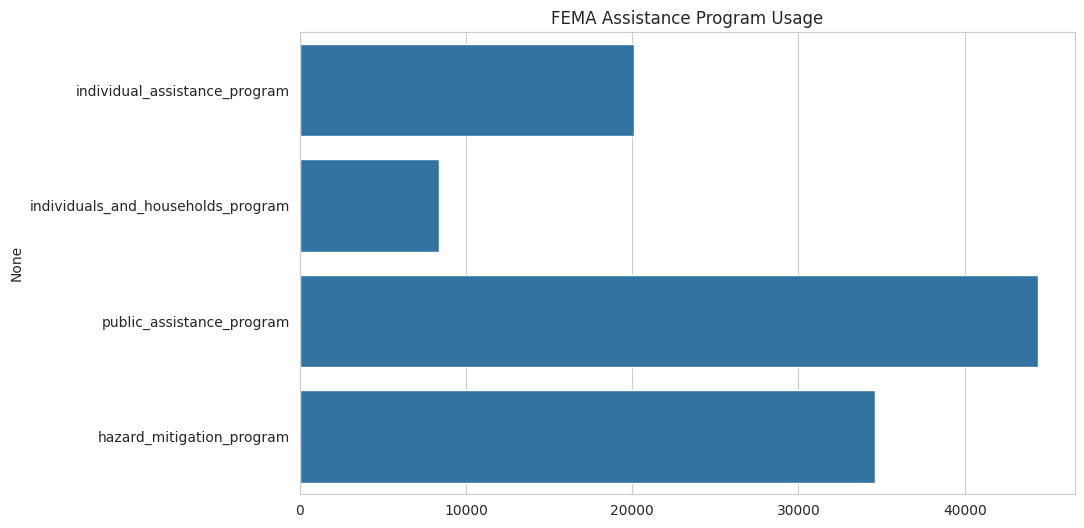

In [6]:
program_cols = [
    "individual_assistance_program",
    "individuals_and_households_program",
    "public_assistance_program",
    "hazard_mitigation_program"
]

assistance_sum = df[program_cols].sum()

plt.figure()

sns.barplot(x=assistance_sum.values, y=assistance_sum.index)

plt.title("FEMA Assistance Program Usage")

plt.show()

<Axes: xlabel='disaster_type'>

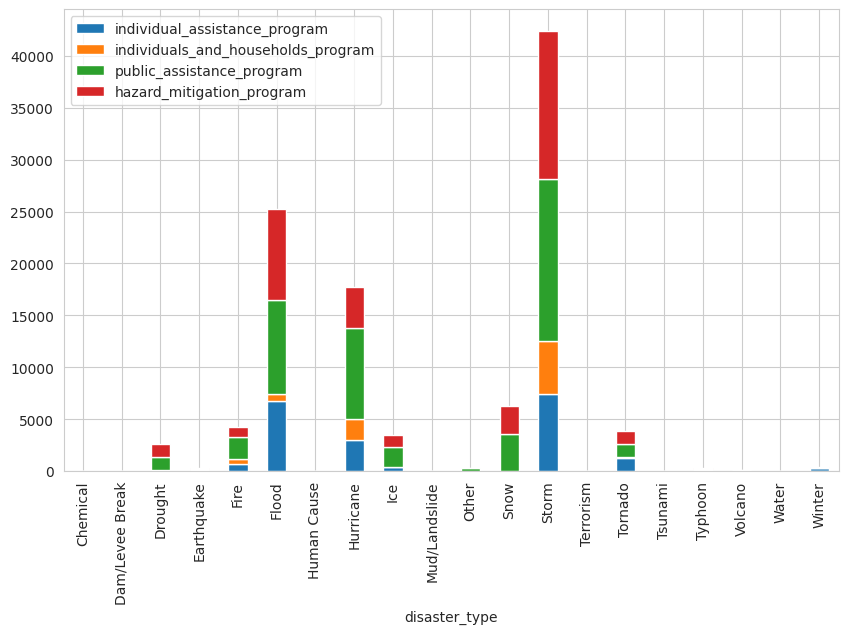

In [7]:
assistance_by_type = df.groupby("disaster_type")[program_cols].sum()

assistance_by_type.plot(kind="bar", stacked=True)

## Future Disaster Risk & Advanced Analysis
This section analyzes future disaster trends, FEMA assistance patterns,
and key factors influencing disaster frequency.

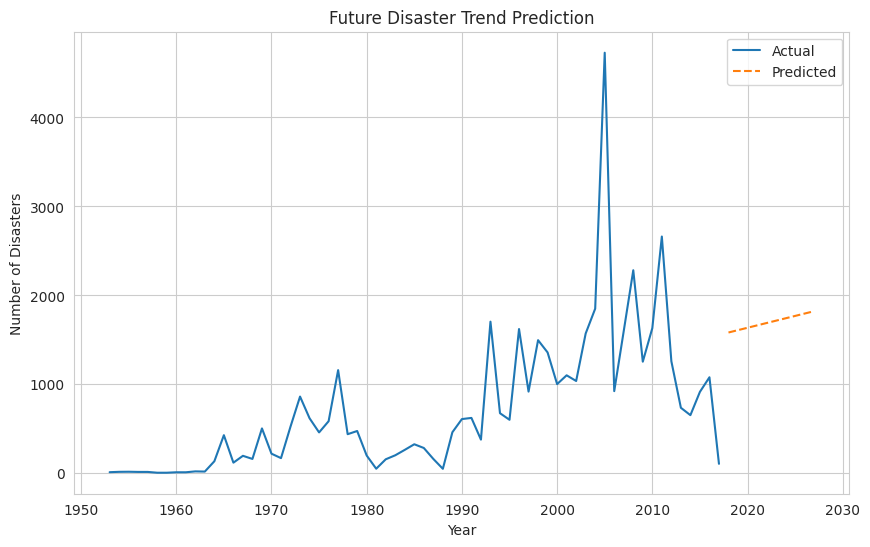

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
yearly = df.groupby("year").size().reset_index(name="disasters")

X = yearly["year"].values.reshape(-1,1)
y = yearly["disasters"].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict future (next 10 years)
future_years = np.arange(df["year"].max()+1, df["year"].max()+11).reshape(-1,1)
future_preds = model.predict(future_years)

# Combine for plotting
plt.figure()

plt.plot(yearly["year"], y, label="Actual")
plt.plot(future_years, future_preds, linestyle="--", label="Predicted")

plt.title("Future Disaster Trend Prediction")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()

plt.show()

#Factors Driving Disaster Frequency

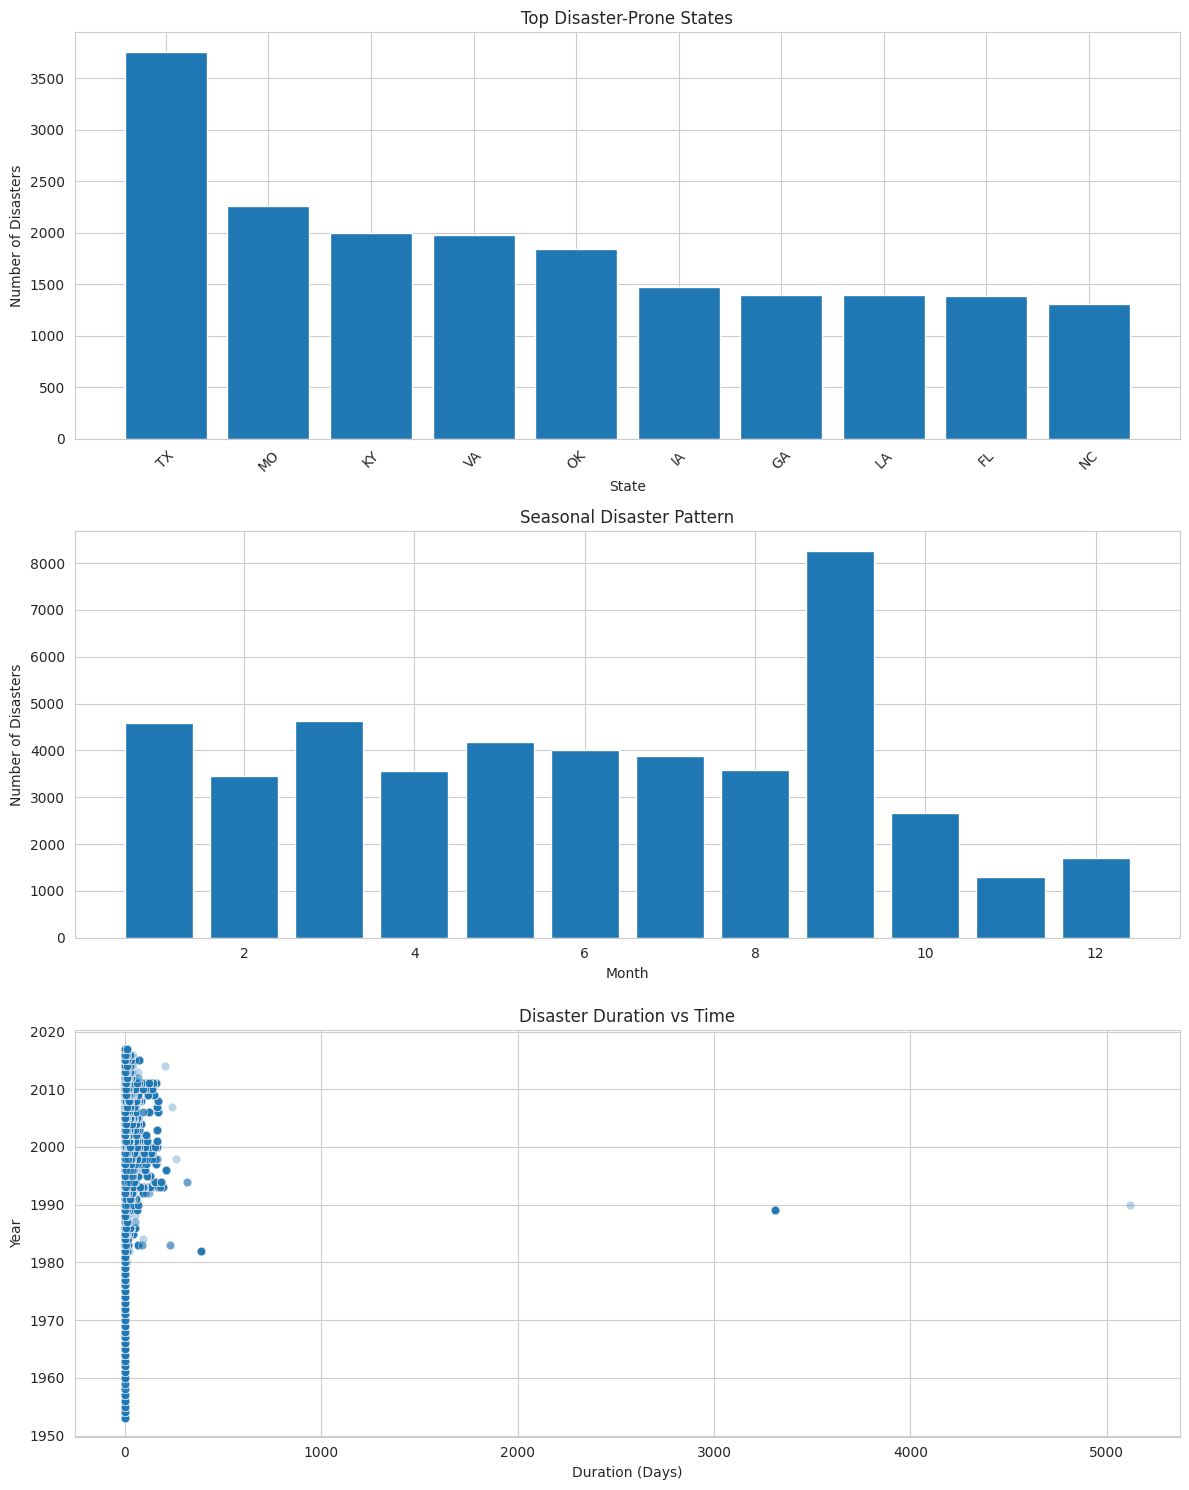

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# -----------------------------
# 1. Top Disaster-Prone States
# -----------------------------
state_counts = df.groupby("state").size().sort_values(ascending=False).head(10)

axes[0].bar(state_counts.index, state_counts.values)

axes[0].set_title("Top Disaster-Prone States")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of Disasters")
axes[0].tick_params(axis='x', rotation=45)


# -----------------------------
# 2. Seasonal Disaster Pattern
# -----------------------------
monthly = df.groupby("month").size()

axes[1].bar(monthly.index, monthly.values)

axes[1].set_title("Seasonal Disaster Pattern")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Disasters")


# -----------------------------
# 3. Disaster Duration vs Time
# -----------------------------
sns.scatterplot(
    x=df["disaster_duration_days"],
    y=df["year"],
    alpha=0.3,   # reduces clutter
    ax=axes[2]
)

axes[2].set_title("Disaster Duration vs Time")
axes[2].set_xlabel("Duration (Days)")
axes[2].set_ylabel("Year")


# -----------------------------
# Add grid to all plots
# -----------------------------
for ax in axes:
    ax.grid(True)


# Adjust layout
plt.tight_layout()

# Show final figure
plt.show()

#Correaltion btw Disaster Features

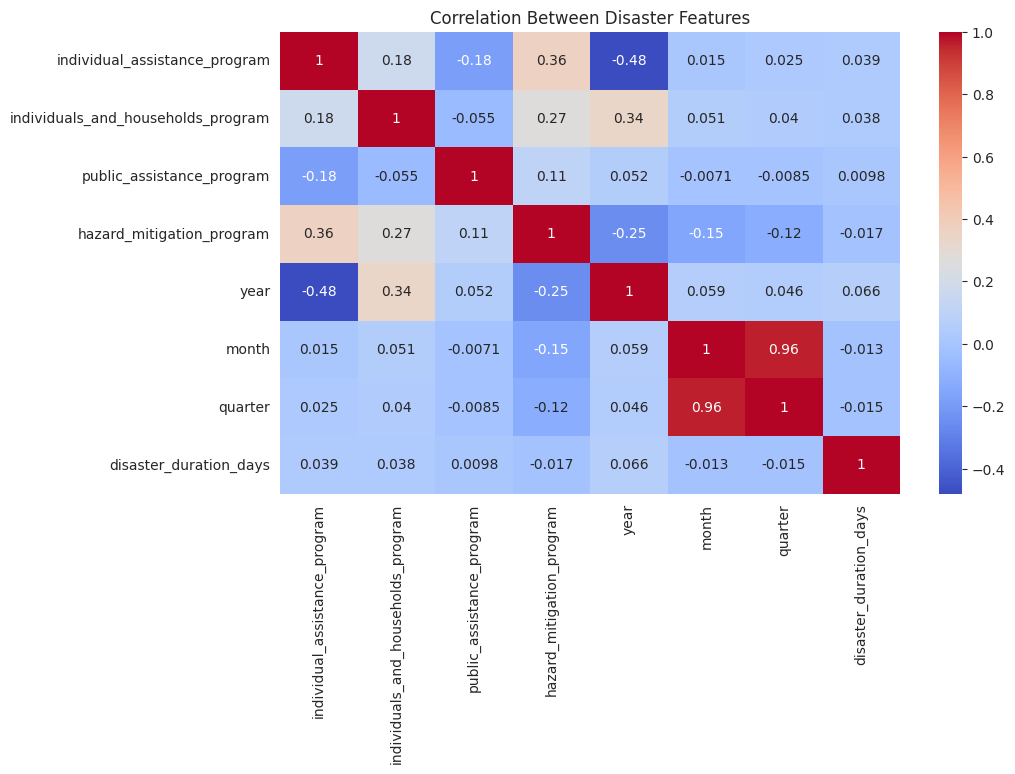

In [17]:
plt.figure()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Between Disaster Features")

plt.show()

#Risk Categorization

In [12]:
df["risk_level"] = pd.cut(
    df["disaster_duration_days"],
    bins=[0,5,20,100,1000],
    labels=["Low","Medium","High","Extreme"]
)

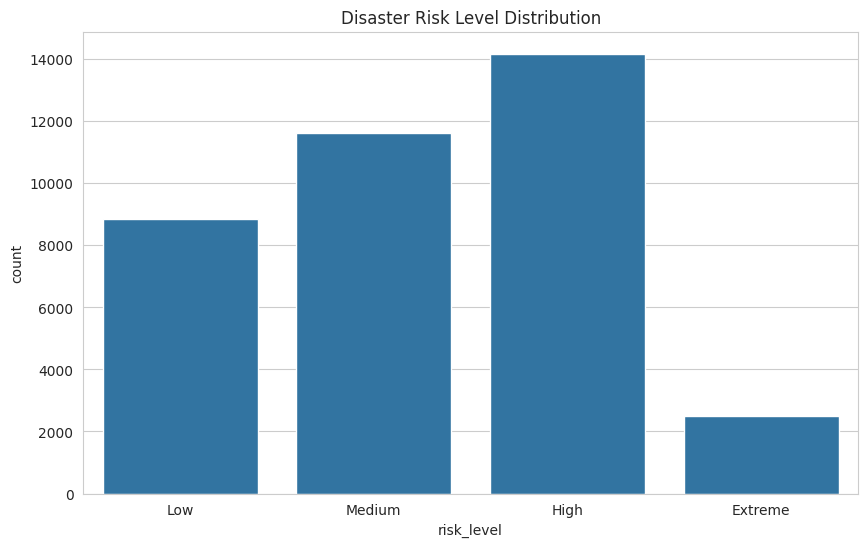

In [13]:
sns.countplot(data=df, x="risk_level")

plt.title("Disaster Risk Level Distribution")

plt.show()

#Choropleth Map
maps to show geographical distribution of disasters

In [14]:
import plotly.express as px
state_data = df.groupby("state").size().reset_index(name="disaster_count")

state_data.head()

,state,disaster_count
0,AK,155
1,AL,1199
2,AR,1282
3,AS,55
4,AZ,210


In [15]:
fig = px.choropleth(
    state_data,
    locations="state",
    locationmode="USA-states",
    color="disaster_count",
    hover_name="state",
    hover_data={"disaster_count": True},
    scope="usa",
    color_continuous_scale="Reds"
)
fig.update_layout(
    title="US Disaster Declarations by State"
)

fig.show()